In [ ]:
import pandas as pd
import numpy as np
import xgboost as xgb
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import classification_report, accuracy_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.preprocessing import OrdinalEncoder
from ucimlrepo import fetch_ucirepo 
  
# fetch dataset 
phishing_websites = fetch_ucirepo(id=327) 
  
# data (as pandas dataframes) 
X = phishing_websites.data.features 
y = phishing_websites.data.targets 

le = LabelEncoder()
y = le.fit_transform(y.values.ravel())
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

X_train = X_train.to_numpy()
X_test = X_test.to_numpy()

counts = np.bincount(y_train)
sqrt_weights = 1.0 / np.sqrt(counts)
sqrt_weights = sqrt_weights / np.sum(sqrt_weights) * len(counts)
sample_weights_sqrt = np.array([sqrt_weights[cls] for cls in y_train])

model = xgb.XGBClassifier(
    tree_method='hist',
    device='cuda',
    random_state=1,
    # n_estimators=200,
    # learning_rate=0.1,
    # max_depth=3,
    # subsample = 1.0
)

param_grid = {
    'n_estimators': [400],
    'max_depth': [7],
    'learning_rate': [0.1],
    'subsample': [0.8]
}

grid_search = GridSearchCV(
    estimator=model,
    param_grid=param_grid,
    scoring='accuracy',
    cv=5, 
    verbose=1,
    n_jobs=-1
)

print("Начало обучения (Grid Search)...")

grid_search.fit(X_train, y_train, sample_weight=sample_weights_sqrt)
best_model = grid_search.best_estimator_

y_pred = best_model.predict(X_test)

print("\n--- Результаты ---")
print(f"Лучшие параметры: {grid_search.best_params_}")
print(f"Точность (Accuracy) на тесте: {accuracy_score(y_test, y_pred):.3f}")
best_model.save_model("phishing_xgb_model.json")

#Загрузка потом:
# import xgboost as xgb
# new_model = xgb.XGBClassifier()
# new_model.load_model("phishing_xgb_model.json")

Начало обучения (Grid Search)...
Fitting 5 folds for each of 1 candidates, totalling 5 fits

--- Результаты ---
Лучшие параметры: {'learning_rate': 0.1, 'max_depth': 7, 'n_estimators': 400, 'subsample': 0.8}
Точность (Accuracy) на тесте: 0.976



--- Топ-5 важных признаков ---
1. sslfinal_state: 0.2785
2. url_of_anchor: 0.2050
3. prefix_suffix: 0.1670
4. sfh: 0.0267
5. web_traffic: 0.0207


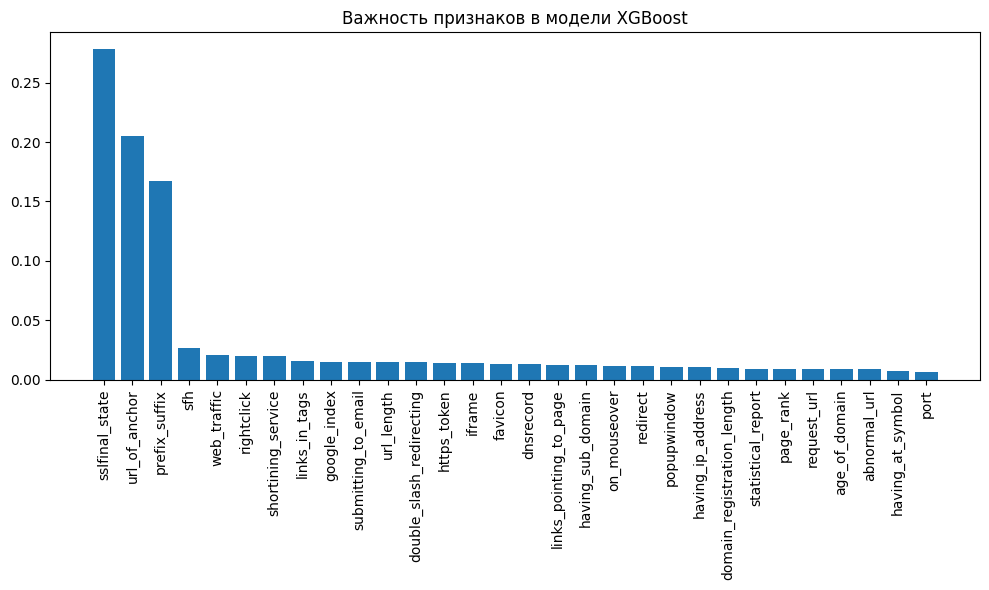

In [27]:
import matplotlib.pyplot as plt

# Получаем важность признаков
importances = best_model.feature_importances_
feature_names = phishing_websites.data.features.columns

# Сортируем
indices = np.argsort(importances)[::-1]

print("\n--- Топ-5 важных признаков ---")
for f in range(5):
    print(f"{f + 1}. {feature_names[indices[f]]}: {importances[indices[f]]:.4f}")

# Визуализация
plt.figure(figsize=(10, 6))
plt.title("Важность признаков в модели XGBoost")
plt.bar(range(len(importances)), importances[indices])
plt.xticks(range(len(importances)), [feature_names[i] for i in indices], rotation=90)
plt.tight_layout()
plt.show()

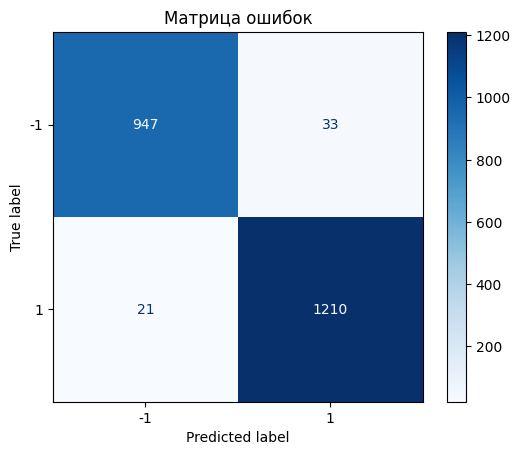

In [19]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_)
disp.plot(cmap=plt.cm.Blues)
plt.title("Матрица ошибок")
plt.show()

In [12]:
y_train_pred = best_model.predict(X_train)
train_acc = accuracy_score(y_train, y_train_pred)
test_acc = accuracy_score(y_test, y_pred) 

print(f"Точность на обучении: {train_acc:.3f}")
print(f"Точность на тесте: {test_acc:.3f}")
print(f"Разница: {train_acc - test_acc:.3f}")

Точность на обучении: 0.990
Точность на тесте: 0.976
Разница: 0.014


In [13]:
cv_results = grid_search.cv_results_
mean_test_scores = cv_results['mean_test_score']
std_test_scores = cv_results['std_test_score']

print(f"Средняя оценка на кросс-валидации: {grid_search.best_score_:.3f}")
print(f"Стандартное отклонение между фолдами: {std_test_scores[grid_search.best_index_]:.4f}")

Средняя оценка на кросс-валидации: 0.971
Стандартное отклонение между фолдами: 0.0012


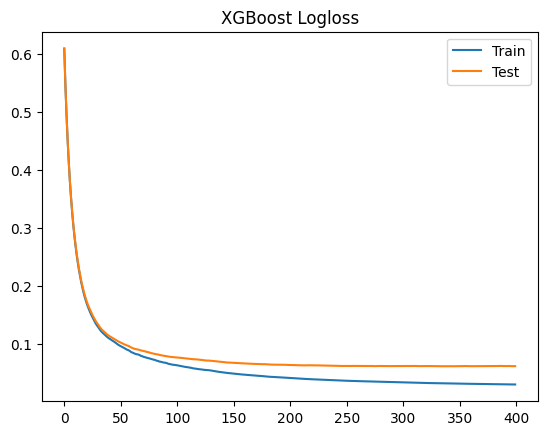

In [16]:
# Нужно передать eval_set в метод fit
best_model.fit(
    X_train, y_train,
    eval_set=[(X_train, y_train), (X_test, y_test)],
    verbose=False
)

results = best_model.evals_result()
import matplotlib.pyplot as plt

plt.plot(results['validation_0']['logloss'], label='Train')
plt.plot(results['validation_1']['logloss'], label='Test')
plt.title('XGBoost Logloss')
plt.legend()
plt.show()